In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

### Load data

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")
results = np.load("Results/rollout_global/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
feature_names_short = ['1,5-Anhydrosorbitol', '2-Aminobutyric \n acid', '2-Hydroxybutyric \n acid', 
                       '2-Oxoglutaric \n acid', '3-Hydroxyisobutyric \n acid', 'Acetic \n acid', 
                       'Acetoacetic \n acid', 'Acetone', 'Alanine', 'Albumin', 
                       'Apolipoprotein B', 'Arginine', 'Asparagine', 'Aspartate', 
                       'BCAA to AAA \n ratio', 'Betaine', 'Bilirubin', 'C reactive \n protein', 
                       'Calcium', 'Choline', 'Citric \n acid', 'Creatine', 'Creatinine', 
                       'Cystine', 'D-Galactose', 'Dimethylamine', 'Dimethylsulfone', 
                       'Erythrocyte \n sedimentation \n rate', 'Erythrocytes', 
                       'Estimated \n Glomerular \n Filtration \n Rate', 'Ethanol', 'Formic acid', 
                       'Glucose', 'Glutamic \n acid', 'Glutamine', 
                       'Glutamine to \n glutamate ratio', 'Glyc A', 'GlycB to \n GlycA ratio', 
                       'Glycerol', 'Glycine', 'HDL cholesterol', 'Histidine', 'Iron', 
                       'LDL cholesterol', 'Lactate to \n pyruvate ratio', 'Lactic acid', 
                       'Leucine', 'Leukocytes', 'Lipoprotein(a)', 'Lysine', 
                       'Methanol', 'Methionine', 'Myo-inositol', 'N,N-Dimethylglycine', 
                       'Non-albumin \n protein', 'Ornithine', 'Phenylalanine', 'Platelets', 
                       'Proline', 'Pyruvic \n acid', 'SPC', 'Sarcosine', 'Serine', 
                       'Succinic \n acid', 'Threonine', 'Transferrin', 'Triglycerides', 
                       'Trimethylamine-N-oxide', 'Tyrosine', 'Urate', 'Urea', 
                       'Urea to creatinine \n ratio']

In [4]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

### Interaction graph (top-k)

In [5]:
def select_top_nodes(R, feature_names, top_m=15):
    importance = R.sum(axis=0)  # received attention
    
    top_idx = np.argsort(importance)[-top_m:]
    top_idx = top_idx[np.argsort(importance[top_idx])[::-1]]
        
    R_sub = R[np.ix_(top_idx, top_idx)]
    imp_sub = importance[top_idx]
    feature_names_sub = [feature_names[i] for i in top_idx]

    return R_sub, imp_sub, feature_names_sub, top_idx

In [6]:
R_sub, imp_sub, feature_names_sub, top_idx = select_top_nodes(results['rollout'], 
                                                     feature_abbrev, 
                                                     top_m=15)

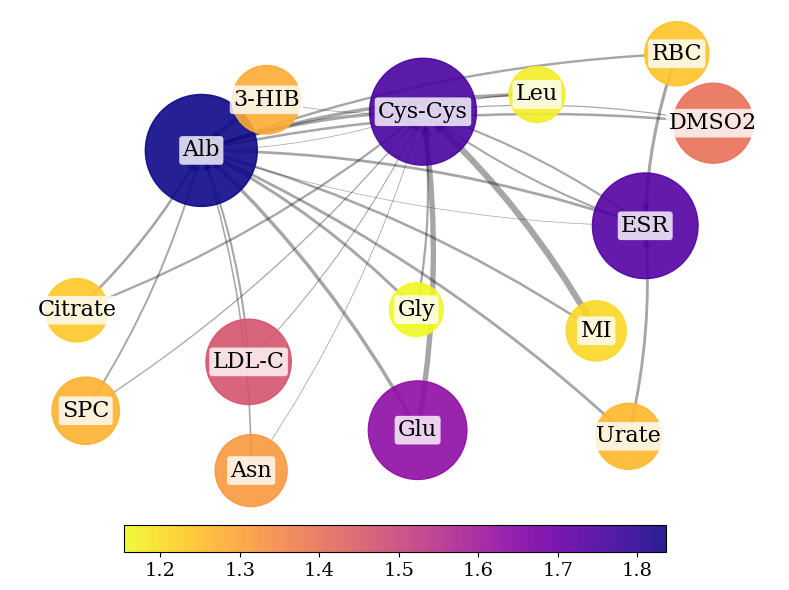

In [7]:
plt.rcParams.update({"font.family": "serif"})

R_sub = np.asarray(R_sub, dtype=float)
n = R_sub.shape[0]

# Remove self-loops
W = R_sub.copy()
np.fill_diagonal(W, 0.0)

# Node statistics
# received_attention = R_sub.sum(axis=0)
received_attention = imp_sub

normalize = True

if normalize: 
    row_sums = R_sub.sum(axis=1, keepdims=True)
    P = np.divide(R_sub, row_sums, out=np.zeros_like(R_sub), where=row_sums > 0)
else: 
    P = R_sub
    
entropy = -np.sum(np.where(P > 0, P * np.log(P), 0.0), axis=1)
# entropy = entropy / np.log(n)

# Edge selection
mask = np.zeros_like(W, dtype=bool)

top_k_out = 2
for i in range(n):
    idx = np.argsort(W[i, :])[-top_k_out:]
    mask[i, idx] = W[i, idx] > 0
    
# Build graph
G = nx.DiGraph()
for j, name in enumerate(feature_names_sub):
    G.add_node(j, label=name)

for i in range(n):
    for j in range(n):
        if mask[i, j]:
            G.add_edge(i, j, weight=W[i, j])

# Layout
pos = nx.spring_layout(G, weight="weight", seed=7, k=1 / np.sqrt(n))

# Visual scaling
node_sizes = 1500 + 5000 * (
    (received_attention - received_attention.min())
    / (received_attention.max() - received_attention.min() + 1e-12)
)

edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.5 + 4.0 * (
    (edge_weights - edge_weights.min())
    / (edge_weights.max() - edge_weights.min() + 1e-12)
) if len(edge_weights) > 0 else []

figsize=(8,6)
cmap='plasma_r'

plt.figure(figsize=figsize)

nodes = nx.draw_networkx_nodes(G,
                               pos,
                               node_size=node_sizes,
                               node_color=received_attention,
                               cmap=cmap,
                               alpha=0.9
                              )

nx.draw_networkx_edges(G, 
                       pos,
                       width=edge_widths, 
                       alpha=0.35, 
                       arrows=True, 
                       arrowsize=10, 
                       connectionstyle="arc3,rad=0.08"
                      )

labels = nx.draw_networkx_labels(G, 
                                 pos, 
                                 labels={j: feature_names_sub[j] for j in range(n)}, 
                                 font_size=16, 
                                 font_color="black",
                                 font_family="serif"
                                )

# Add white background (halo effect)
for text in labels.values():
    text.set_bbox(dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
        boxstyle="round,pad=0.15"
    ))

cbar = plt.colorbar(nodes,
                    orientation="horizontal",
                    fraction=0.05,   # thickness of the bar
                    pad=0.02         # distance from the plot
                   )

cbar.ax.tick_params(labelsize=14)

plt.axis("off")
plt.tight_layout()

# plt.savefig("Results/graph_plot.pdf", dpi=600, bbox_inches="tight")

plt.show()

### Attention matrices

In [8]:
with open("Results/rollout_local/attn_matrices.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

In [9]:
attn_list = [np.mean(attn_matrices[key]['attn_matrix'], axis=0) for key in attn_matrices.keys()]

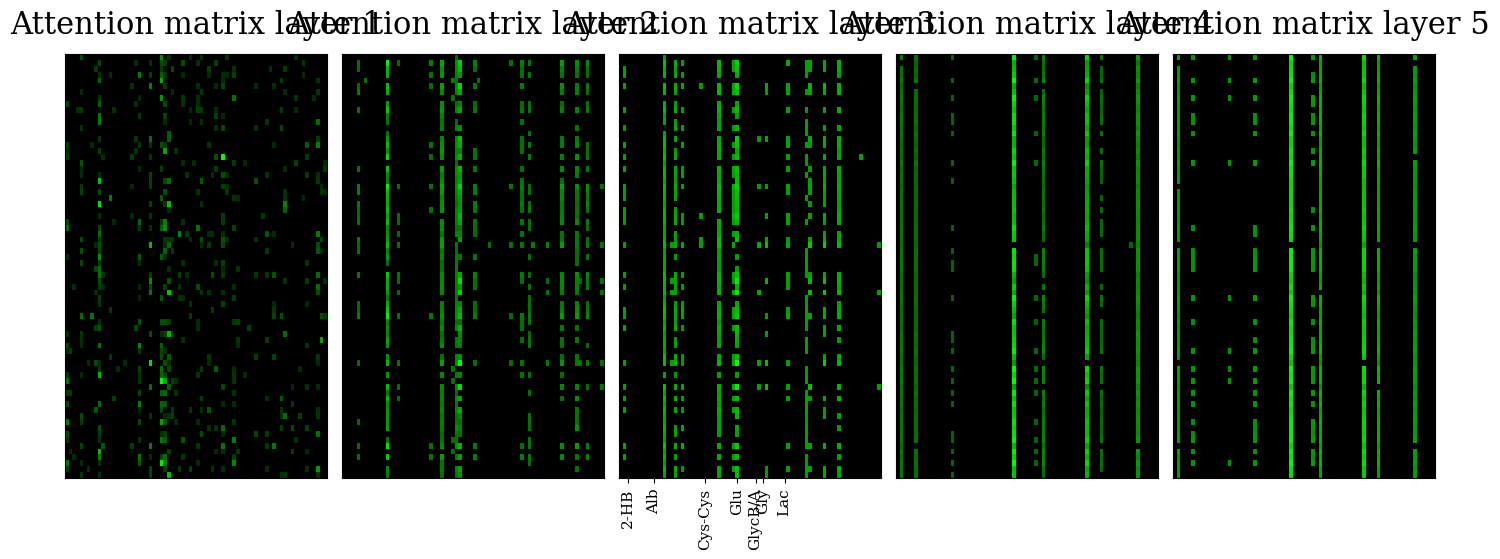

In [10]:
lst_plot = ['2-HB', 'Alb', 'Cys-Cys', 'Glu', 'GlycB/A', 'Gly', 'Lac']
indices = [i for i, x in enumerate(feature_abbrev) if x in lst_plot]

plt.rcParams.update({
    # "font.size": 8,
    "font.family": "serif",
    # "axes.linewidth": 0.6,
    # "xtick.major.width": 0.6,
    # "ytick.major.width": 0.6,
    # "xtick.major.size": 3,
    # "ytick.major.size": 0,
    # "pdf.fonttype": 42,
    # "ps.fonttype": 42,
    # "svg.fonttype": "none",
})

n_plot = len(attn_list)

fig, axes = plt.subplots(1, n_plot, figsize=(14,5.7))

cmap_attn = LinearSegmentedColormap.from_list("black_green",
                                              ["black", "#00FF00"])    

for (i, attn_matrix) in enumerate(attn_list):
    matrix = attn_matrix.copy()
    np.fill_diagonal(matrix, 0)
    matrix = sparsify_global_percentile(matrix, q=90, keep_diagonal=False)

    axes[i].imshow(matrix, aspect='auto', cmap=cmap_attn)
    axes[i].set_title(rf"Attention matrix layer {i+1}", fontsize = 22, pad=15)     
             
    # plt.title(title, fontsize=40, pad=10)   

    if i == 2:
        axes[i].set_xticks(ticks=indices,
                    labels=lst_plot,
                    rotation=90,
                    fontsize=11)
    else: 
        axes[i].set_xticks([])
        
    axes[i].set_yticks([])
    
plt.tight_layout()
# plt.savefig("Results/attention_matrices.pdf", bbox_inches="tight")
plt.show()

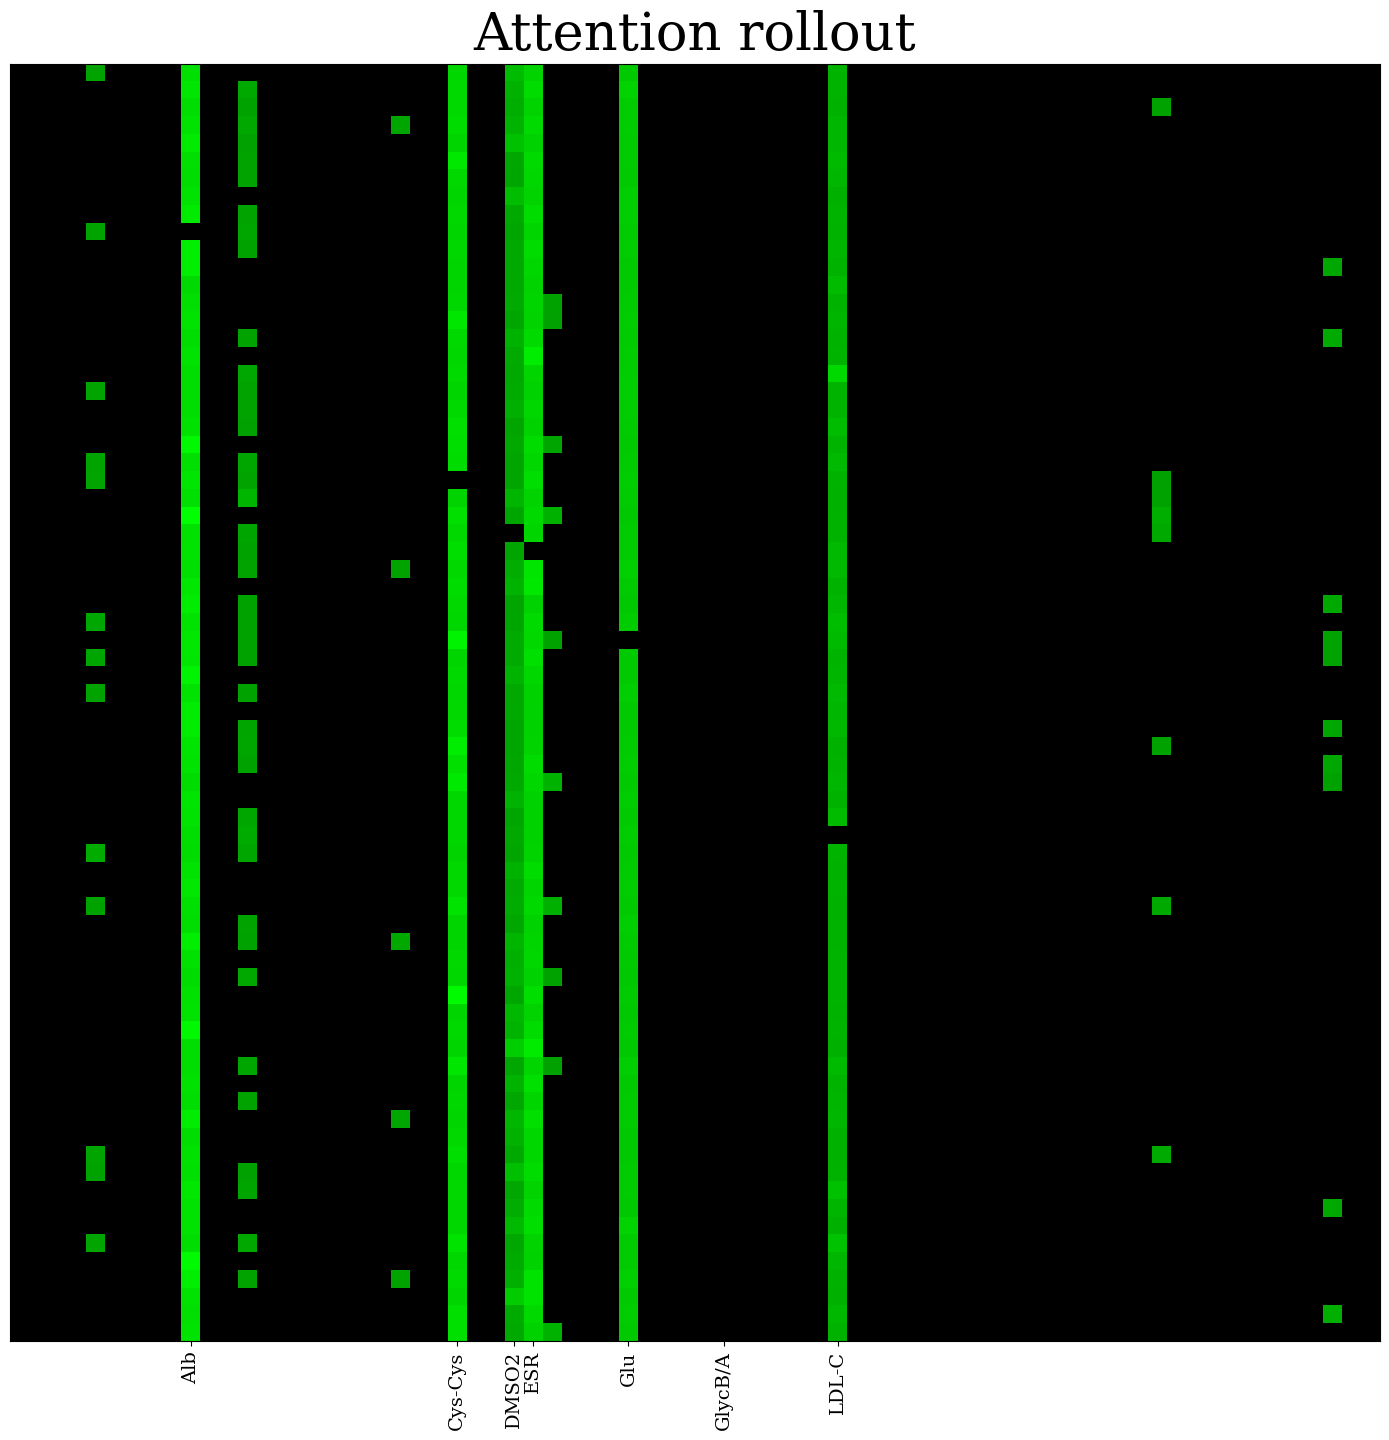

In [11]:
lst_plot_R = ['Alb', 'Cys-Cys', 'DMSO2', 'ESR', 'Glu', 'GlycB/A', 'LDL-C']
indices_R = [i for i, x in enumerate(feature_abbrev) if x in lst_plot_R]

R = results['rollout']
np.fill_diagonal(R, 0)
R = sparsify_global_percentile(R, q=90, keep_diagonal=False)

# plt.figure(figsize=(10, 11))
plt.figure(figsize=(14, 14.5))
im = plt.imshow(R, aspect='auto', cmap=cmap_attn)

plt.title("Attention rollout", fontsize=38, pad=10)   

# plt.xticks(ticks=np.arange(len(feature_abbrev)),
#            labels=feature_abbrev,
#            rotation=90,
#            fontsize=11)

plt.xticks(ticks=indices_R,
           labels=lst_plot_R,
           rotation=90,
           fontsize=14)

plt.yticks([])

plt.tight_layout()
# plt.savefig("Results/attention_rollout.pdf", bbox_inches="tight")
plt.show()